Name: Muhammad Tayyab Abdullah Malik

Email: tayyababdullah75@gmail.com
                        
                            Data Science Bootcamp by GDG CUI Wah                                 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_excel('student_performance_dataset.xlsx')

# Print shape, column names, and data types using df.info()
print(df.info())
print(f"Printing the shape: {df.shape}")

# Print first and last 5 rows
display(df.head())
display(df.tail())

#Statistical summary
display(df.describe())

#Now we check the missing values
print("\nMissing Values:") 
print(df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB
None
Printing the shape: (205, 14)


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
200,185,Waseem,23,Male,Karachi,SE,Intermediate,85.0,7.0,6.0,9,NaN,No,46
201,38,Ayesha,23,Male,Wah,CS,Intermediate,71.0,4.0,9.0,13,87.0,Yes,51
202,68,AYESHA,24,Male,Lahore,CS,Bachelors,70.0,4.0,5.0,5,NaN,No,40
203,180,Ali,25,MALE,Islamabad,EE,Intermediate,NaN,4.0,9.0,6,55.0,Yes,44
204,52,Ahmed,24,FEMALE,Wah,ME,Bachelors,60.0,3.0,8.0,10,53.0,Yes,40


,Student_ID,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Final_Score
count,205.000000,189.000000,200.000000,195.000000,205.000000,195.000000,205.000000
mean,100.600000,76.841270,4.190000,7.030769,11.395122,67.876923,46.819512
std,58.049303,15.771513,1.985854,1.950172,4.521731,15.100530,11.450302
min,1.000000,-10.000000,1.000000,4.000000,5.000000,40.000000,40.000000
25%,51.000000,66.000000,3.000000,5.000000,7.000000,55.000000,40.000000
50%,100.000000,79.000000,4.000000,7.000000,11.000000,67.000000,45.000000
75%,151.000000,87.000000,6.000000,9.000000,15.000000,80.000000,50.000000
max,200.000000,115.000000,7.000000,10.000000,19.000000,94.000000,150.000000



Missing Values:
Student_ID            0
Name                  0
Age                   0
Gender                0
City                  0
Department            0
Education_Level       0
Attendance_%         16
Study_Hours_Daily     5
Assignments          10
Quizzes               0
Midterm              10
Internet_Access       0
Final_Score           0
dtype: int64


Observations
1. Firstly, most of the datatype is string beacuse the data inside them in not refined. Example: For the Age, there is a variation in the data, that is either displayed as numerical or alphabetical.
2. df.describe() describes the the count for the Student ID is 205, but the max value is 200, which means some of the values are repeated/ duplicate.
3. Multiple numerical columns like Midterm, Study_Hours_Daily, and Attendance_% contain missing null values that need to be handled before modeling.

        Step 2: Data Cleaning

In [4]:
# 1. Fix Gender
df['Gender'] = df['Gender'].str.title()    # .str.title() standardizes mixed casings (e.g, 'mAlE','MALE')to a uniform 'Male' or 'Female'.

# 2. Fix Name
df['Name']= df['Name'].str.title() # .str.title() ensures that all names follow proper title case formatting.

# 3. Fix Department
df['Department']= df['Department'].str.upper()
df['Department']= df['Department'].str.strip()
# they will remove the spaces and transform the data to the uppercase

# 4. Fix Age 
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') # errors='coerce' turns text like "twenty" into NaN.
df['Age'] = df['Age'].fillna(df['Age'].median()) ### we used the median because it is not robust unlike the mean, like a single large value can 
# significantly affects the mean. So median is suitable as it is aligned with the center of the values of data

# 5. Fix Impossible Values of attendence and Final_score with nan
# We must replace out-of-bounds values of attendence with NaN first.
df.loc[(df['Attendance_%'] < 0)|(df['Attendance_%']>100), 'Attendance_%'] =np.nan 
df.loc[df['Final_Score'] > 100, 'Final_Score'] = np.nan

# 6. Columns to fill with median
# we will fill all of these numerical columns which contains NaN with median
cols_to_fill = ['Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm', 'Final_Score']
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

# 7. Remove Duplicate Rows
df = df.drop_duplicates() # we are removing these duplicate rows as it unnecessarily inflate our dataset

# 8. Final check
print(df.isnull().sum())

Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64


        Step 3: EDA + Visualization

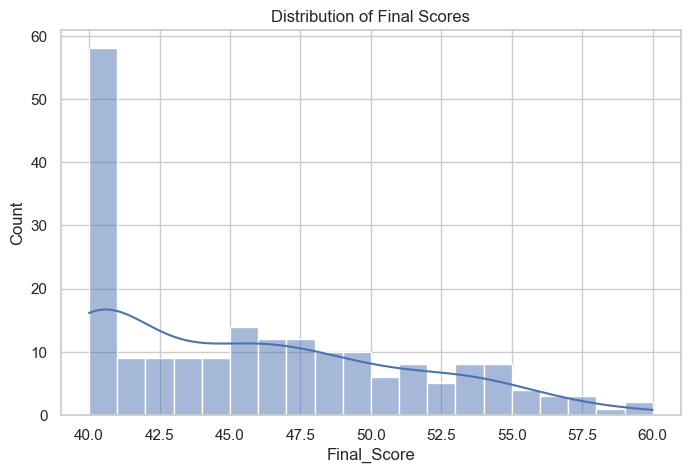

In [5]:
sns.set_theme(style="whitegrid")

# 1. Histplot: Distribution of Final Score
plt.figure(figsize=(8, 5))
sns.histplot(df['Final_Score'], kde=True, bins=20)
plt.title('Distribution of Final Scores')
plt.show()

# Interpretation: 
# The final scores are heavily clustered around the 40 to 55 range.
# Very few students achieved scores above 60 which means that the overall grading might be strict or the assessments were highly challenging.

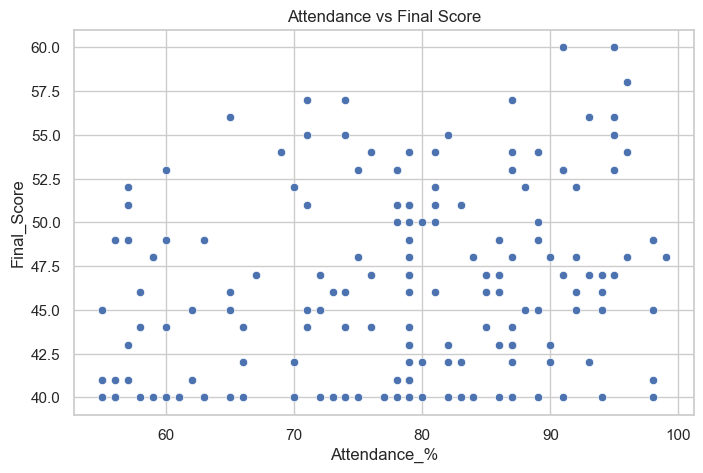

In [6]:
# 2. Scatter: Attendance_% vs Final_Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Attendance_%', y='Final_Score', data=df)
plt.title('Attendance vs Final Score')
plt.show()

# Interpretation:
# There is a loose positive cluster visible from the left to right and its making a positive relationship suggesting that while extremely low attendance might negatively impact grades, 
# but also perfect attendance alone does not guarantee a top score, as there are students with high attendance but low final scores.

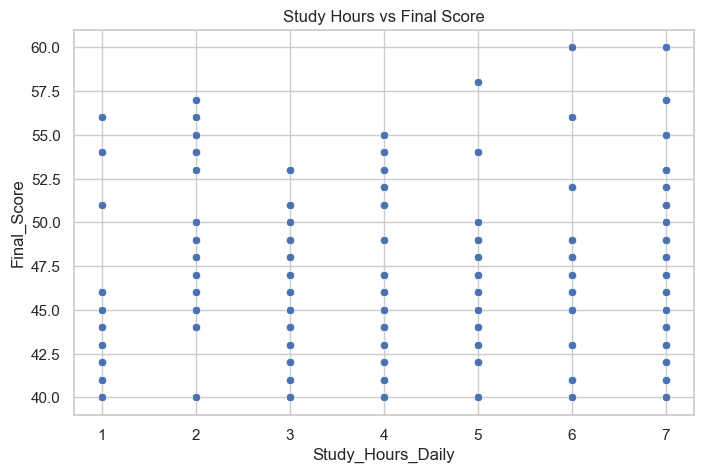

In [7]:
# 3. Scatter: Study_Hours_Daily vs Final_Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Study_Hours_Daily', y='Final_Score', data=df)
plt.title('Study Hours vs Final Score')
plt.show()

# Interpretation:
# The data points are widely dispersed with no strong linear upward trend. 
# This indicates that the large quantity of study hours does not directly translate to higher final scores,
# which could be due to factors such as quality of study materials or individual learning styles.

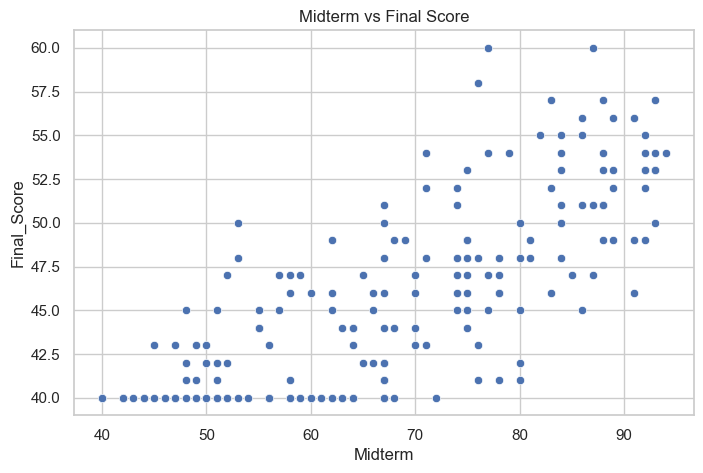

In [8]:
# 4. Scatter: Midterm vs Final_Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Midterm', y='Final_Score', data=df)
plt.title('Midterm vs Final Score')
plt.show()

# Interpretation:
# There is a distinct and strong positive correlation visible between the two variables.
# Students who perform well on the midterm consistently maintain that higher performance in the final assessment which makes it a strong predictive feature.

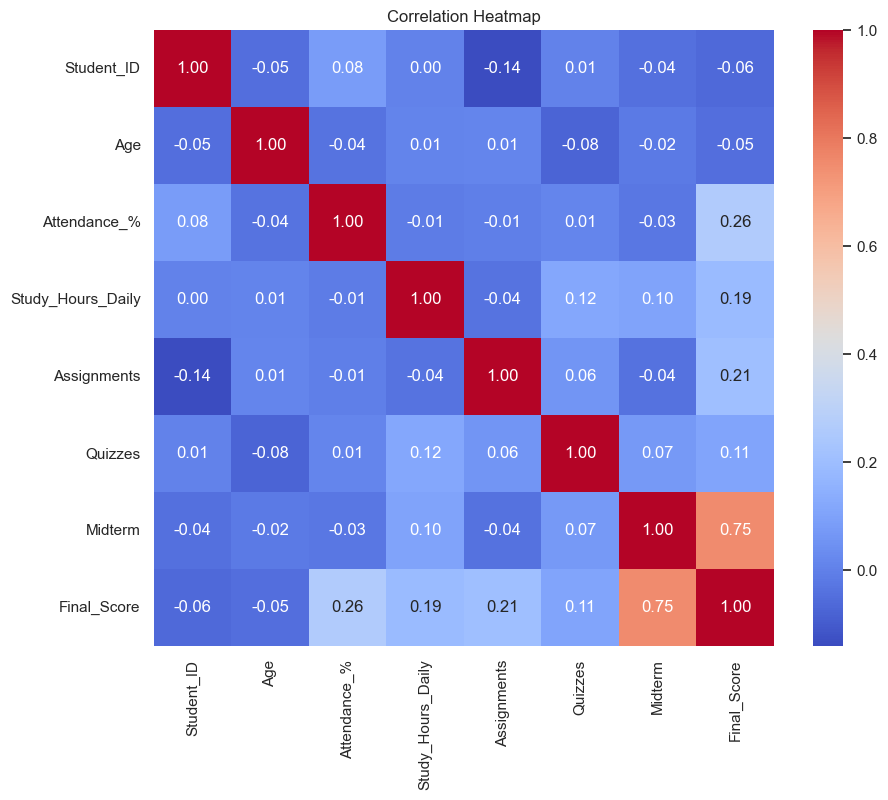

In [9]:
# 5. Heatmap: Correlation of all numerical columns
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Interpretation:
# The heatmap confirms mathematically that Midterm and Assignments hold the strongest positive correlations with the target Final_Score, due to their number is 1.0 (positive correlation).

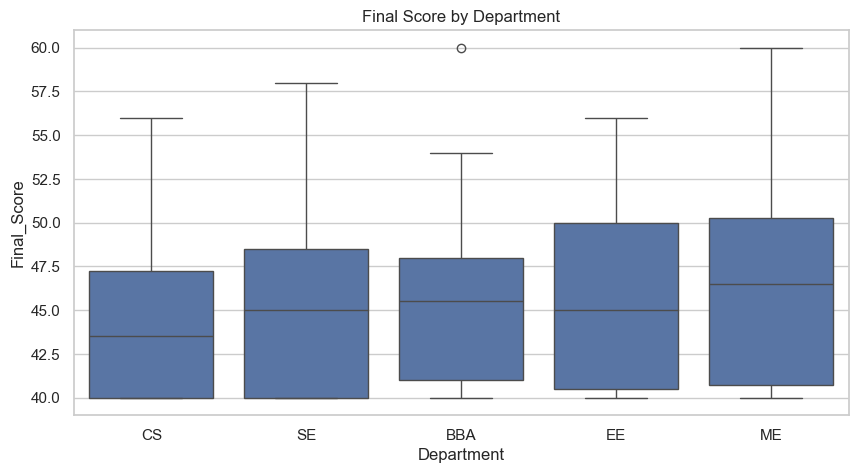

In [10]:
# 6. Boxplot: Final Score grouped by Department
plt.figure(figsize=(10, 5))
sns.boxplot(x='Department', y='Final_Score', data=df)
plt.title('Final Score by Department')
plt.show()

# Interpretation:
# The median final scores are remarkably consistent across all departments,
# sitting near the mid-40s. However, the CS and EE departments exhibit a wider variance in scores and possess more high-performing outliers.


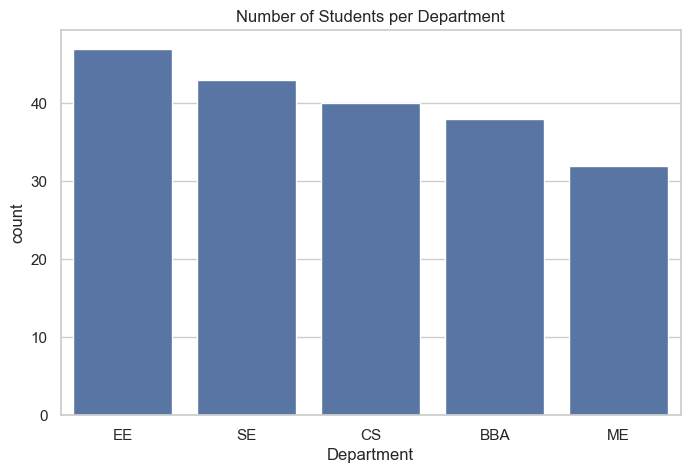

In [11]:
# 7. Countplot: Students per Department
plt.figure(figsize=(8, 5))
sns.countplot(x='Department', data=df, order=df['Department'].value_counts().index)
plt.title('Number of Students per Department')
plt.show()

# Interpretation:
# The dataset is not perfectly balanced across disciplines as the EE and SE departments hold the 
# highest number of student records, whereas ME contains the fewest students.

Actionable Insights:

1. Because the midterm score is the single strongest predictor of final success, implementing early intervention programs immediately after midterm results are released could directly improve final outcomes.

2. Neither raw attendance percentages nor reported daily study hours correlate strongly with the final score. Educational focus should shift away from only tracking time spent and toward evaluating the quality and method of study.

3. Since median scores and distributions are fairly flat across all departments, core academic struggles are likely universal rather than subject-specific. Broad academic skills workshops will benefit the entire student body equally


        Step 4: Feature Engineering + sklearn Pipeline

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression

# Feature Extraction
df['Total_Academic'] = df['Midterm'] + (df['Assignments'] * 5) + (df['Quizzes'] * 2)

# Create Attendance_Category
# Bins continuous attendance percentages into Ordinal categories.
df['Attendance_Category'] = pd.cut(df['Attendance_%'], bins=[0, 60, 80, 100], labels=['Low', 'Medium', 'High']) 

# Drop irrelevant columns
# IDs and Names hold no predictive value and will confuse the model.
X = df.drop(columns=['Student_ID', 'Name', 'Final_Score'])
y = df['Final_Score']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining the Column Groups
num_cols = ['Age', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm', 'Total_Academic']
onehot_cols = ['Gender', 'City', 'Department', 'Internet_Access']
ordinal_cols = ['Education_Level', 'Attendance_Category']

# Build Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ('cat_ordinal', OrdinalEncoder(categories=[['Intermediate', 'Bachelors', 'Masters'], ['Low', 'Medium', 'High']]), ordinal_cols)
    ])

# Build the complete pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),('model', LinearRegression())
    ])

        Step 5: Model Building + Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# train and predict
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Print actual vs predicted for the first 10 students
print("First 10 Predictions:")
comparison_df = pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': np.round(y_pred[:10], 2)})
print(comparison_df)

First 10 Predictions:
   Actual  Predicted
0    52.0      53.30
1    47.0      52.54
2    40.0      46.17
3    48.0      45.33
4    42.0      41.54
5    43.0      42.65
6    50.0      48.02
7    53.0      50.70
8    45.0      46.71
9    41.0      49.64


In [15]:
# Seeing what the model learned
trained_model = pipeline.named_steps['model']

onehot_features = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(onehot_cols)
all_features = num_cols + list(onehot_features) + ordinal_cols
coef_df = pd.DataFrame({'Feature': all_features, 'Weight': trained_model.coef_})
print("\nFeature Weights (Sorted):")
print(coef_df.sort_values(by='Weight', ascending=False))
print(f"\nIntercept (Bias): {trained_model.intercept_}")


Feature Weights (Sorted):
                Feature    Weight
5               Midterm  2.635667
1          Attendance_%  1.883239
6        Total_Academic  1.856096
12      City_Rawalpindi  0.912470
17        Department_ME  0.799209
3           Assignments  0.521847
7         Gender_Female  0.387355
2     Study_Hours_Daily  0.358032
18        Department_SE  0.352772
10         City_Karachi  0.244124
19   Internet_Access_No  0.091642
0                   Age  0.075384
16        Department_EE  0.059768
11          City_Lahore  0.052671
20  Internet_Access_Yes -0.091642
14       Department_BBA -0.153053
21      Education_Level -0.156046
9        City_Islamabad -0.319917
8           Gender_Male -0.387355
4               Quizzes -0.764692
22  Attendance_Category -0.841737
13             City_Wah -0.889348
15        Department_CS -1.058696

Intercept (Bias): 46.75735674267974


The feature with the highest weight is Midterm with a value of 2.635667. This tells that the Midterm is the strongest predictor of a student's final score, meaning for every 1-point increase in a Midterm grade the model predicts the largest positive jump in the final outcome.

In [16]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n...Model evaluation report...")
print(f"MAE(Mean absolute error):{mae:.2f}")
print(f"RMSE(root mean squared error):{rmse:.2f}")
print(f"R squared: {r2:.2f}")


...Model evaluation report...
MAE(Mean absolute error):2.45
RMSE(root mean squared error):3.27
R squared: 0.59


1. On average our model's predictions are off by 2.45 points from the actual final scores.
2. The typical error is 3.27 points; because this is higher than the MAE, it indicates there are some students with larger prediction errors that are being penalized.
3. Our model explains 59% of the patterns and variations found in the students' final scores.

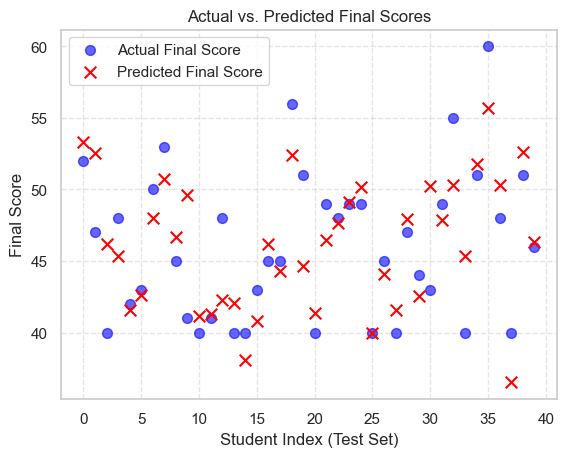

In [20]:
# Fixed Visualization
y_test_reset = y_test.reset_index(drop=True)

# Plot Actuals as Blue Dots
plt.scatter(y_test_reset.index, y_test_reset, color='blue', marker='o', label='Actual Final Score', alpha=0.6, s=50)
plt.scatter(y_test_reset.index, y_pred, color='red', marker='x', label='Predicted Final Score', s=70)
plt.xlabel('Student Index (Test Set)')
plt.ylabel('Final Score')
plt.title('Actual vs. Predicted Final Scores')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('student_performance_comparison.png')

# Interpretation: The closer the blue dots are to the red dashed line, the better the model.
# If dots stray far from the line the model struggled to predict those specific student scores accurately.

The chart shows that the model is generally accurate, as most red crosses (predictions) follow the same pattern and stay close to the blue dots (actual scores).
However some larger gaps between the markers suggest that while the model captures the overall trend, it occasionally struggles with specific students whose performance doesn't strictly follow the patterns in the data.

    Conclusion:

    In short, building this model showed me exactly what drives student success. The model quickly learned that a student's Mmdterm score is the absolute best clue for predicting their final score, with everyday efforts like quizzes and assignments contributing to it. Overall, the model achieved an R² score of 0.59, which basically means it successfully explains about 59% of the grading puzzle using the data I gave it. However, that leaves 41% of a student's performance unaccounted for! If I were to improve this project in the future, I would want to collect more data that goes beyond just academics—like a student's sleep schedule, or stress levels to help capture that missing human element and make the predictions even sharper.

A model isn’t just about accuracy but it’s about trust and usefulness.
If a model has R² = 0.65 but you understand it, you can explain results and take action (like improving student performance).
A model with R² = 0.95 but no explanation is risky because no one knows how it works.
Very high accuracy can also mean problems like overfitting or data leakage.
Understanding your model helps you improve it by adding better data.
So, a slightly less accurate but explainable model is more valuable in real life.